# EDA data from folder Data

In [9]:
import os
import json
import re
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Data path
file_path = r"d:\create\Agenttic-RAG-for-e-commerce\data for system\cellphones_data\dien-thoai\dien-thoai_products_cleaned.json"
category_name = "Điện thoại" if "dien-thoai" in file_path else "Laptop"

In [16]:
with open(file_path, 'r', encoding='utf-8') as f:
    cleaned_data = json.load(f)
    
df = pd.DataFrame(cleaned_data)

In [17]:
print(f"================ EDA DỮ LIỆU SẠCH: {category_name.upper()} ================")
print(f"1. Tổng số sản phẩm (Dòng): {df.shape[0]}")
print(f"2. Tổng số trường thông tin (Cột): {df.shape[1]}")
print("\nDanh sách các cột trong dữ liệu sạch:")
print(list(df.columns))

================ EDA DỮ LIỆU SẠCH: ĐIỆN THOẠI ================
1. Tổng số sản phẩm (Dòng): 396
2. Tổng số trường thông tin (Cột): 27

Danh sách các cột trong dữ liệu sạch:
['product_id', 'name', 'brand', 'sku', 'url', 'category', 'price', 'special_price', 'final_price', 'stock', 'cpu', 'ram', 'storage', 'display_size', 'display_resolution', 'battery', 'os', 'gpu', 'weight', 'thumbnail', 'image_url', 'description', 'included_accessories', 'camera_primary', 'camera_secondary', 'camera_video', 'dimensions']


In [18]:
print("\n3. Thống kê tỷ lệ Null và kiểm tra HTML sót lại trên từng cột:")
print(f"{'Tên cột':<22} | {'% Rỗng (Null)':<15} | {'Số dòng còn HTML':<18}")
print("-" * 62)

html_pattern = re.compile(r'<[^>]+>')
for col in df.columns:
    null_pct = (df[col].isnull().sum() / len(df)) * 100
    
    # Đếm số dòng còn chứa ký tự HTML
    sample_vals = df[col].dropna()
    html_count = sum(1 for val in sample_vals if isinstance(val, str) and html_pattern.search(val))
    
    print(f"{col:<22} | {null_pct:>13.2f}% | {html_count:>18}")


3. Thống kê tỷ lệ Null và kiểm tra HTML sót lại trên từng cột:
Tên cột                | % Rỗng (Null)   | Số dòng còn HTML  
--------------------------------------------------------------
product_id             |          0.00% |                  0
name                   |          0.00% |                  0
brand                  |          0.76% |                  0
sku                    |          0.00% |                  0
url                    |          0.00% |                  0
category               |          0.00% |                  0
price                  |          0.00% |                  0
special_price          |          0.00% |                  0
final_price            |          0.00% |                  0
stock                  |          0.00% |                  0
cpu                    |         18.94% |                  0
ram                    |         10.35% |                  0
storage                |          1.01% |                  0
display_size      

In [19]:
print("\n4. Top 5 thương hiệu xuất hiện nhiều nhất:")
brand_counts = df['brand'].value_counts()
print(brand_counts.head(5))

print("\n5. Thống kê thông số giá cả (VNĐ):")
price_stats = df[['price', 'final_price']].describe()
# Định dạng hiển thị tiền tệ cho dễ đọc
pd.options.display.float_format = '{:,.0f}'.format
print(price_stats)


4. Top 5 thương hiệu xuất hiện nhiều nhất:
brand
Apple      116
Samsung     66
Xiaomi      48
OPPO        45
Nubia       25
Name: count, dtype: int64

5. Thống kê thông số giá cả (VNĐ):
           price  final_price
count        396          396
mean  17,053,876   14,525,063
std   13,409,656   11,494,997
min      230,000      230,000
25%    5,690,000    4,940,000
50%   12,990,000   10,490,000
75%   26,622,500   22,990,000
max   64,990,000   64,990,000


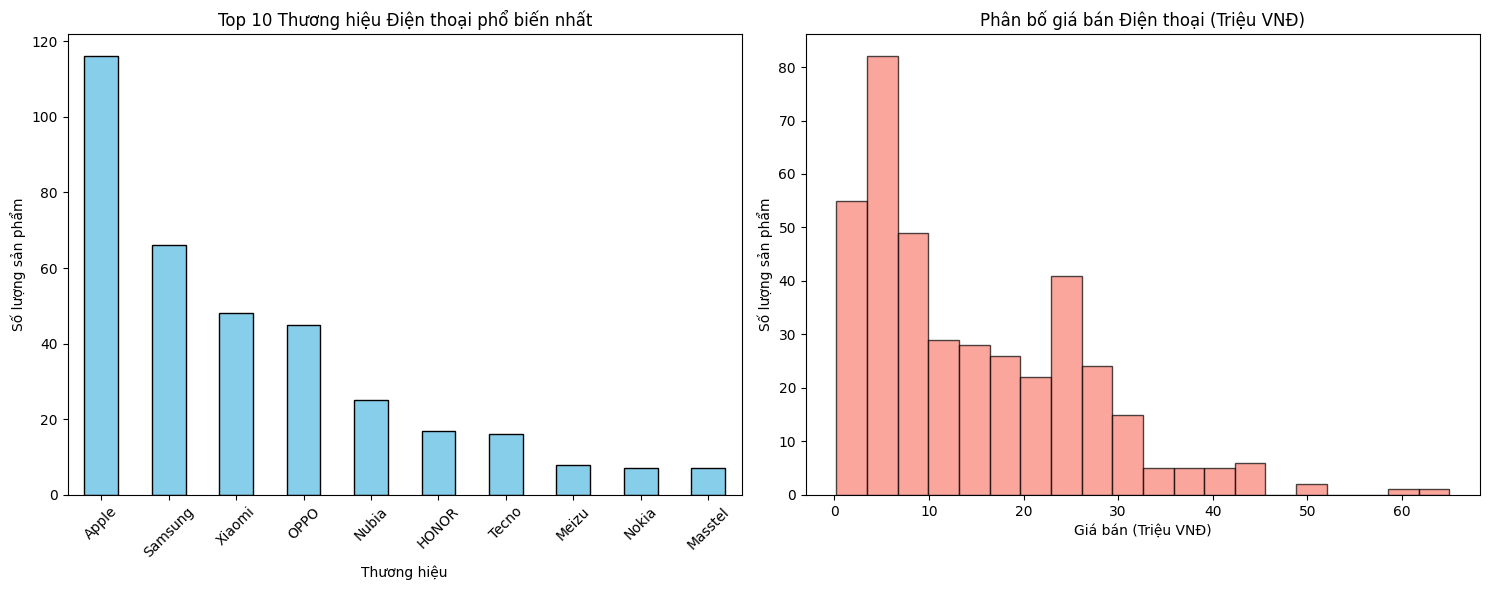

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Biểu đồ 1: Top 10 thương hiệu hàng đầu
top_brands = brand_counts.head(10)
top_brands.plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title(f"Top 10 Thương hiệu {category_name} phổ biến nhất")
axes[0].set_ylabel("Số lượng sản phẩm")
axes[0].set_xlabel("Thương hiệu")
axes[0].tick_params(axis='x', rotation=45)

# Biểu đồ 2: Phân bố giá bán thực tế (Final Price)
# Lọc bỏ giá trị NaN và chuyển đổi sang triệu VNĐ để trục X gọn hơn
prices_in_million = df['final_price'].dropna() / 1_000_000
axes[1].hist(prices_in_million, bins=20, color='salmon', edgecolor='black', alpha=0.7)
axes[1].set_title(f"Phân bố giá bán {category_name} (Triệu VNĐ)")
axes[1].set_xlabel("Giá bán (Triệu VNĐ)")
axes[1].set_ylabel("Số lượng sản phẩm")

plt.tight_layout()
plt.show()